In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules
import os
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs

ngs.SetNumThreads(8)

In [2]:
import config_dict as cfg                    # config = physical & simulation parameters
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"


import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D"
box_medium = "PLASMA" # "VACUUM" or "PLASMA"

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.001, d_gap=0.002,
                                         Lx_wg_active=0.08, Lx_wg_passive=0.02,
                                         Ly_wg=0.07)
    num_active=6
    is_PAM=False
    antenna_grill.add_module(num_active, is_PAM, delta_phi_deg=-90, power_module_W=6.0)
    # antenna_grill.add_module(num_active, is_PAM, delta_phi_deg=-90, power_module_W=1.0e6,
    #                         klystron_phase_offset_deg=90)
    instructions = antenna_grill.generate_mesh_instructions()
    #antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

In [3]:
# %%capture
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()
p_order=3
GF_E_field, Gamma_R, Gamma_T, diag_data, amr_history = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium, p_order)

==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 3.36e-02m,    Lx_tot: 8.36e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.22e-01m, Lz_pml: 1.21e-01m, Lz_tot: 3.65e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺ (edge): 2.41+0.00j, n_⟂⁺ (core): 2.41
λ_⟂⁺ (core): 3.36e-02m 
n_⟂-:0.00+1.73j, λ_⟂⁻: 4.68e-02m
==== 
Lz_wall: 0.00e+00m 
Lz_source: 1.22e-01m
[MESH GENERATED !]
Lx_wg: 0.00e+00m, wg_medium: VACUUM
Waveguide medium is not PLASMA, wg_is_plasma set to 0.0
==== 
#DoFs = 294098

--- AMR Iteration 1/20 ---
Degrees of Freedom: 294098
==== 
w_size_R: 5.0454e-02m,    w_size_T: 6.0769e-02m
Gamma_R (SWR) = 3.906e-01

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): 5.3410e-03 W/m
Net Power Exiting to PMLs:    4.7700e-03 W/m
Plasma Bulk Conservation Error: 1.07e+01 %
called base class apply, complex, type = N5ngfem25BlockDifferentialOperatorE
called base class apply, complex, type = N5ngfem25BlockDifferentialOperatorE
called base class apply, c

In [4]:
# solver.plot_radial_density_profile()

In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra)
#run_folder_tot_path = "/Users/remibellon/Interships/IRFM_2026/LH_coupling_code_remi/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260807_101040
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260807_101040


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.122, Lz_wall: 0.000, Lz_pml: 0.121, Lz_tot: 0.365
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 2.41e+00+0.00e+00j, n_perp_m: 0.00e+00+1.73e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260807_101040/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 3.36e-02
 Lx_tot: 8.36e-02
 Lz_plasma: 1.22e-01
 Lz_pml: 1.21e-01
 Lz_tot: 3.65e-01
 P_in_net: 4.57e-03
 P_out_Radial: 1.48e-03
 P_out_Toroidal: 3.10e-03
 eta_pred_R: 7.61e-04
 eta_pred_T: 4.29e-17
 eta_sim_R: 9.58e-01
 eta_sim_T: 8.68e-01
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-186.8005952617502+0j)
 lambda_perp_real: 3.36e-02
 n_para_imag: 0.00e+00
 n_para_real: 2.00e+00
 peak_x_T: 2.83e-02
 peak_z_R: 1.16e-01
 power_error_plasma: 1.09e-03
 window_size_radial: 5.05e-02
 window_size_toroidal

/Home/RB286887/LH_coupling_code_remi/aloha_fem/.venv/lib/python3.11/site-packages/matplotlib/text.py:1012: ComplexWarning: Casting complex values to real discards the imaginary part
  x = float(self.convert_xunits(self._x))
/Home/RB286887/LH_coupling_code_remi/aloha_fem/.venv/lib/python3.11/site-packages/matplotlib/text.py:1013: ComplexWarning: Casting complex values to real discards the imaginary part
  y = float(self.convert_yunits(self._y))
/Home/RB286887/LH_coupling_code_remi/aloha_fem/.venv/lib/python3.11/site-packages/matplotlib/text.py:863: ComplexWarning: Casting complex values to real discards the imaginary part
  posx = float(self.convert_xunits(x))
/Home/RB286887/LH_coupling_code_remi/aloha_fem/.venv/lib/python3.11/site-packages/matplotlib/text.py:864: ComplexWarning: Casting complex values to real discards the imaginary part
  posy = float(self.convert_yunits(y))
/Home/RB286887/LH_coupling_code_remi/aloha_fem/.venv/lib/python3.11/site-packages/matplotlib/transforms.py:1913:

--- Plot saved to /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260807_101040/Ez_map.pdf ---


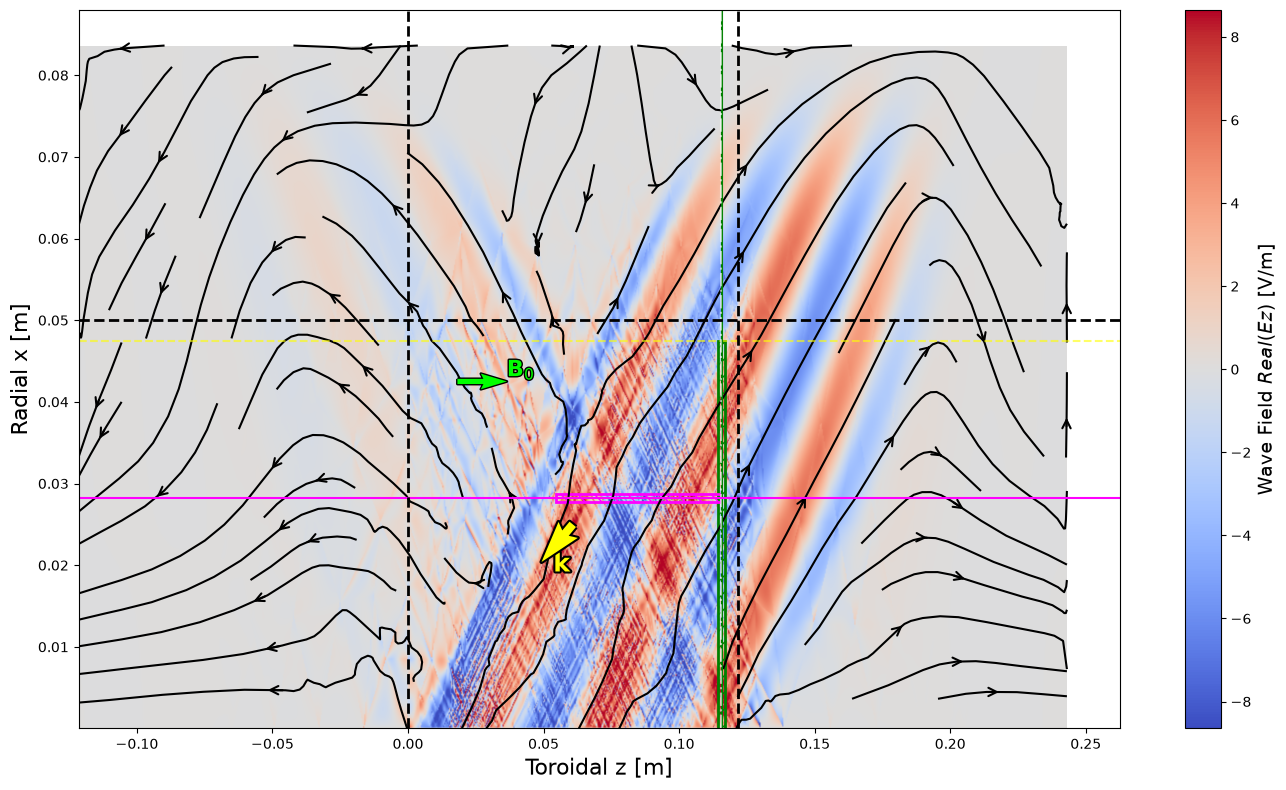

In [5]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)

Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',

                         antenna_grill=antenna_grill, Lz_wall=Lz_wall, plot_poynting=True, show_windows_R=True, show_windows_T=True, Poynting_box=False)

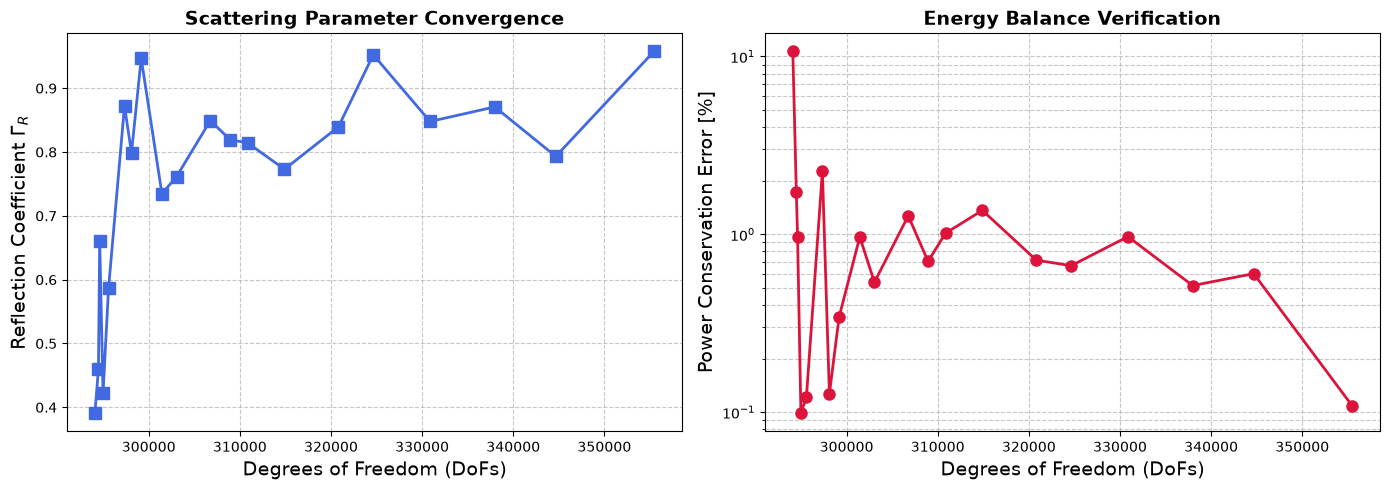

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_amr_convergence(amr_history):
    ndofs = np.array(amr_history['ndofs'])
    gamma_R = np.array(amr_history['gamma_R'])
    gamma_T = np.array(amr_history['gamma_T'])
    power_error = np.array(amr_history['power_error'])

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Figure A: Reflection Coefficient Convergence
    ax1.plot(ndofs, gamma_R, marker='s', color='royalblue', lw=2, markersize=8)
    ax1.set_xlabel("Degrees of Freedom (DoFs)", fontsize=14)
    ax1.set_ylabel(r"Reflection Coefficient $\Gamma_R$", fontsize=14)
    ax1.set_title("Scattering Parameter Convergence", fontsize=14, fontweight='bold')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    # Figure B: Transmission Coefficient Convergence
    ax2.plot(ndofs, gamma_T, marker='s', color='royalblue', lw=2, markersize=8)
    ax2.set_xlabel("Degrees of Freedom (DoFs)", fontsize=14)
    ax2.set_ylabel(r"Transmission Coefficient $\Gamma_T$", fontsize=14)
    ax2.set_title("Scattering Parameter Convergence", fontsize=14, fontweight='bold')
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    # Figure C: Power Conservation Error
    # We use a log scale because a proper FEM solver should drop exponentially
    ax3.semilogy(ndofs, power_error * 100, marker='o', color='crimson', lw=2, markersize=8)
    ax3.set_xlabel("Degrees of Freedom (DoFs)", fontsize=14)
    ax3.set_ylabel("Power Conservation Error [%]", fontsize=14)
    ax3.set_title("Energy Balance Verification", fontsize=14, fontweight='bold')
    ax3.grid(True, which='both', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("AMR_Convergence_Proof.pdf", dpi=300)
    plt.show()

# Call this after your solver finishes
plot_amr_convergence(amr_history)

yes
no
yes2


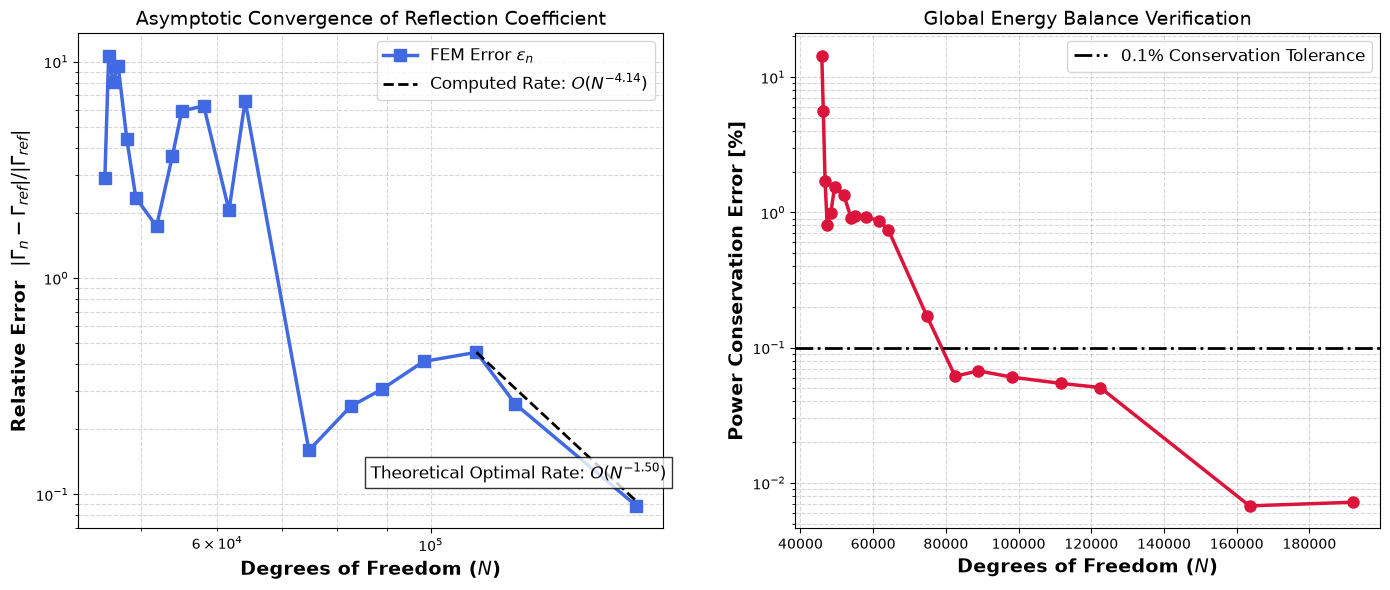

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_amr_analysis(amr_history, order=3):
    """
    Generates publication-quality figures to prove mathematical convergence
    and global energy conservation of the FEM solver.
    """
    print('yes')
    ndofs = np.array(amr_history['ndofs'])
    gamma_R = np.array(amr_history['gamma_R'])
    power_error = np.array(amr_history['power_error']) * 100.0 # Convert to %

    # 1. Compute Relative Error of the Scattering Parameter
    gamma_ref = gamma_R[-1] # Treat the final hyper-refined step as the exact analytical solution
    relative_error = np.abs(gamma_R[:-1] - gamma_ref) / np.abs(gamma_ref)
    ndofs_eval = ndofs[:-1]

    # Filter out exactly zero errors to avoid log10(0)
    valid_idx = relative_error > 0
    ndofs_eval = ndofs_eval[valid_idx]
    relative_error = relative_error[valid_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    print('no')
    # --- FIGURE A: Asymptotic h-Convergence (Step 1) ---
    ax1.loglog(ndofs_eval, relative_error, marker='s', color='royalblue', lw=2.5, markersize=8, label='FEM Error $\epsilon_n$')

    # Compute the asymptotic slope (using the last 3 points)
    if len(ndofs_eval) >= 3:
        log_dofs = np.log10(ndofs_eval[-3:])
        log_err = np.log10(relative_error[-3:])
        slope, intercept, _, _, _ = linregress(log_dofs, log_err)

        # Plot the theoretical slope reference triangle
        x_ref = np.array([ndofs_eval[-3], ndofs_eval[-1]])
        y_ref = (x_ref / ndofs_eval[-3])**slope * relative_error[-3]
        ax1.loglog(x_ref, y_ref, color='black', linestyle='--', lw=2, label=f'Computed Rate: $O(N^{{{slope:.2f}}})$')

        # Theoretical optimal rate for 2D HCurl is roughly O(N^{-p/2})
        theoretical_slope = -order / 2.0
        ax1.text(0.5, 0.1, f"Theoretical Optimal Rate: $O(N^{{{theoretical_slope:.2f}}})$",
                 transform=ax1.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    ax1.set_xlabel("Degrees of Freedom ($N$)", fontsize=14, fontweight='bold')
    ax1.set_ylabel(r"Relative Error  $|\Gamma_n - \Gamma_{ref}| / |\Gamma_{ref}|$", fontsize=14, fontweight='bold')
    ax1.set_title("Asymptotic Convergence of Reflection Coefficient", fontsize=14)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend(fontsize=12)
    print('yes2')
    # --- FIGURE B: Energy Balance Closure (Step 4) ---
    ax2.semilogy(ndofs, power_error, marker='o', color='crimson', lw=2.5, markersize=8)

    # Plot the acceptable journal tolerance line (0.1%)
    ax2.axhline(y=0.1, color='black', linestyle='-.', lw=2, label='0.1% Conservation Tolerance')

    ax2.set_xlabel("Degrees of Freedom ($N$)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Power Conservation Error [%]", fontsize=14, fontweight='bold')
    ax2.set_title("Global Energy Balance Verification", fontsize=14)
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig("AMR_Expert_Analysis.pdf", dpi=300)
    plt.show()

plot_amr_analysis(amr_history, order=3)

In [9]:
# pp_plot.plot_1D_radial_slice_with_theory(
#     h5_filepath=E_map2D_h5_filepath,
#     cfg=cfg.__dict__,
#     component='Ez',
#     z_eval=0.20)  # None for exact center

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plot_expert_gamma_convergence(multi_run_data, gamma_ref):
    """
    Plots the Relative Error of Gamma vs DoFs to prove singularity mitigation.
    Compares Sharp vs Rounded septa across different p-orders.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = {2: 'royalblue', 3: 'crimson', 4: 'forestgreen'}
    styles = {'Sharp': '--', 'Rounded': '-'}
    markers = {'Sharp': 'x', 'Rounded': 'o'}

    for p_order, geom_data in multi_run_data.items():
        for geom_type, history in geom_data.items():
            ndofs = np.array(history['ndofs'])
            gamma_R = np.array(history['gamma_R'])

            # Compute Relative Error against a highly refined analytical/benchmark reference
            relative_error = np.abs(gamma_R - gamma_ref) / np.abs(gamma_ref)

            # Filter zero errors for log scale
            valid = relative_error > 1e-14
            ndofs_plot = ndofs[valid]
            err_plot = relative_error[valid]

            label = f"$p={p_order}$, {geom_type}"
            ax.loglog(ndofs_plot, err_plot,
                      color=colors.get(p_order, 'black'),
                      linestyle=styles.get(geom_type, '-'),
                      marker=markers.get(geom_type, 'o'),
                      lw=2.5, markersize=8, label=label)

    # Aesthetics
    ax.set_xlabel("Degrees of Freedom ($N$)", fontsize=15, fontweight='bold')
    ax.set_ylabel(r"Relative Error $|\Gamma_R - \Gamma_{ref}| / |\Gamma_{ref}|$", fontsize=15, fontweight='bold')
    ax.set_title("Asymptotic $h$-Convergence: Singularity vs. Fillet", fontsize=16)
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.legend(fontsize=12, loc='lower left', framealpha=0.9)

    plt.tight_layout()
    plt.savefig("Gamma_Convergence_Expert.pdf", dpi=300)
    plt.show()

def plot_expert_power_conservation(multi_run_data):
    """
    Plots the Power Conservation Error vs AMR iterations (or DoFs) to prove
    global energy balance. Scans across p-orders.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = {2: 'royalblue', 3: 'crimson', 4: 'forestgreen'}

    for p_order, geom_data in multi_run_data.items():
        # Power conservation is mostly independent of the fillet; we plot the 'Rounded' case
        if 'Rounded' in geom_data:
            history = geom_data['Rounded']
            ndofs = np.array(history['ndofs'])
            power_error = np.array(history['power_error']) * 100.0 # Convert to %

            label = f"FEM Order $p={p_order}$"
            ax.semilogy(ndofs, power_error,
                        color=colors.get(p_order, 'black'),
                        marker='s', lw=2.5, markersize=8, label=label)

    # Add Journal Tolerance Reference Line
    ax.axhline(y=0.1, color='black', linestyle='-.', lw=2.5, label='0.1% Threshold (Target)')

    # Aesthetics
    ax.set_xlabel("Degrees of Freedom ($N$)", fontsize=15, fontweight='bold')
    ax.set_ylabel("Power Conservation Error [%]", fontsize=15, fontweight='bold')
    ax.set_title("Global Energy Balance vs. Spatial Discretization", fontsize=16)
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.savefig("Power_Conservation_Expert.pdf", dpi=300)
    plt.show()

In [11]:
import copy
from PP_Plot_and_Load import plot_expert_gamma_convergence, plot_expert_power_conservation

# Define the scan space
p_orders = [2, 3, 4]
fillet_radii = {'Sharp': 0.0, 'Rounded': 0.001}

# Initialize the nested dictionary
multi_run_data = {p: {} for p in p_orders}
reference_gamma = None

print("=== STARTING EXPERT MESH CONVERGENCE SCAN ===")

for p in p_orders:
    for geom_name, radius in fillet_radii.items():
        print(f"\n---> RUNNING: p-order = {p} | Geometry = {geom_name} (radius={radius}m)")

        # 1. Update config dynamically
        current_cfg = copy.deepcopy(cfg.__dict__)
        current_cfg['DOMAIN']['septa_fillet_radius'] = radius

        # 2. Initialize Solver
        solver = LHCouplingSolver_2DHcurl_1DH1(current_cfg, geom_mode, box_medium, antenna_grill)

        # 3. Build Mesh & Physics
        mesh = solver.build_mesh_with_PMLs()
        solver.build_physics_Stix_B_field()

        # 4. Solve with AMR (PASS THE p_order!)
        GF_E_field, Gamma_R, Gamma_T, diag_data, amr_history = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium, p_order=p)

        # 5. Store history
        multi_run_data[p][geom_name] = amr_history

        # Assume the p=4 Rounded final step is our "Exact" analytical reference
        if p == 4 and geom_name == 'Rounded':
            reference_gamma = amr_history['gamma_R'][-1]

print("\n=== SCAN COMPLETE. GENERATING PUBLICATION GRAPHS ===")

# Generate Graph 2: Asymptotic Convergence
plot_expert_gamma_convergence(multi_run_data, gamma_ref=reference_gamma)

# Generate Graph 3: Energy Conservation
plot_expert_power_conservation(multi_run_data)

# Extract and plot the ALOHA spectrum for the highest fidelity run (p=4, Rounded)
deep_fields = solver.extract_tangential_aperture_fields(x_target=0.005)
P_net = diag_data['P_in_net']
n_para_array, spectrum_aloha = solver.compute_aloha_normalized_spectrum(deep_fields, P_net)
# Ensure plot_aloha_spectrum is imported and called here

ImportError: cannot import name 'plot_expert_gamma_convergence' from 'PP_Plot_and_Load' (/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/PP_Plot_and_Load.py)

In [ ]:
# Test n_para spectrum
# n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, run_folder_tot_path, x_eval=0.01)


In [ ]:
# wg_s_params = solver.compute_waveguide_S_parameters()


In [ ]:
# ===========================
aperture_fields = solver.extract_tangential_aperture_fields(x_target=0.0)
# # ===========================

import matplotlib.pyplot as plt
import numpy as np

def plot_aperture_fields(field_data, x_target, save_dir=None):
    """
    Plots the complex electric field components along the toroidal (z) direction.
    Ideal for comparing the aperture fields (x=0) with ALOHA.
    """
    z_coords = field_data['z_coords']
    Ez = field_data['Ez']

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot Absolute, Real, and Imaginary parts of Ez (the primary coupled field)
    ax.plot(z_coords, np.abs(Ez), color='black', lw=2.5, label='|E_z| (Amplitude)')
    ax.plot(z_coords, np.real(Ez), color='royalblue', lw=1.5, linestyle='--', label='Re(E_z)')
    ax.plot(z_coords, np.imag(Ez), color='crimson', lw=1.5, linestyle=':', label='Im(E_z)')

    # Formatting
    ax.set_xlabel("Toroidal Position z [m]", fontsize=14)
    ax.set_ylabel("Electric Field E_z [V/m]", fontsize=14)
    ax.set_title(f"Aperture Field Profile at x = {x_target:.4f} m", fontsize=14, fontweight='bold')

    ax.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, left=True, right=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=12, ncol=3)

    plt.tight_layout()

    if save_dir:
        import os
        filepath = os.path.join(save_dir, f"Aperture_Field_x{x_target:.4f}.pdf")
        plt.savefig(filepath, dpi=300)
        print(f"  -> Aperture field plot saved to {filepath}")

    plt.show()
# ===========================
# plot_aperture_fields(aperture_fields, x_target=0.0)
# ===========================



--- Extracting Field Profile at x=0.0000m ---


In [ ]:
# ===========================
deep_fields = solver.extract_tangential_aperture_fields(x_target=0.005)
P_net = diag_data['P_in_net'] # The Poynting flux you already compute
n_para_array, spectrum_aloha = solver.compute_aloha_normalized_spectrum(deep_fields, P_net)
# ===========================

def plot_aloha_spectrum(n_para, power_spectrum, target_n_para=None, save_dir=None):
    """
    Plots the absolute coupled power density spectrum.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(n_para, power_spectrum, color='crimson', lw=1.6, label='FEM Coupled Power')

    # Optional: Plot a vertical marker for the intended injected n_parallel
    if target_n_para is not None:
        ax.axvline(x=target_n_para, color='royalblue', linestyle='--', lw=2,
                   label=f'Target n_// = {target_n_para}')
        ax.axvline(x=-target_n_para, color='royalblue', linestyle='--', lw=2, alpha=0.5)

    # Formatting (Limit the x-axis to the physically relevant spectrum)
    ax.set_xlim(-50, 50)

    # Ensure the Y-axis starts at 0 for a linear power plot
    ax.set_ylim(bottom=0.0)

    ax.set_xlabel("Parallel Refractive Index (n_//)", fontsize=14)
    ax.set_ylabel("Power Density dP/dn_// [W/m]", fontsize=14)
    ax.set_title("Normalized Coupled Power Spectrum", fontsize=14, fontweight='bold')

    ax.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, left=True, right=True)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=12)

    plt.tight_layout()

    if save_dir:
        import os
        filepath = os.path.join(save_dir, "Normalized_Power_Spectrum.pdf")
        plt.savefig(filepath, dpi=300)
        print(f"  -> Spectrum plot saved to {filepath}")

    plt.show()
# ===========================
# plot_aloha_spectrum(n_para_array, spectrum_aloha)
# ===========================



--- Extracting Field Profile at x=0.0050m ---

--- Computing Normalized Power Spectrum (ALOHA Benchmark) ---


In [ ]:
import h5py
chemin_fichier = 'matlab_data_files/saved_scenar_example.mat' # Adaptez le chemin si besoin

def afficher_structure(nom, objet):
    """
    Cette fonction est appelée pour chaque élément trouvé dans le fichier HDF5.
    """
    if isinstance(objet, h5py.Group):
        # C'est une structure MATLAB (un "dossier")
        print(f"📁 Structure : {nom}")

    elif isinstance(objet, h5py.Dataset):
        # C'est une donnée (matrice, vecteur, etc.)
        # On récupère ses dimensions (shape) et son type de donnée (dtype)
        print(f"   ↳ 📄 Donnée : {nom} | Dimensions : {objet.shape} | Type : {objet.dtype}")

# Ouverture et exploration du fichier
print(f"--- Analyse du fichier : {chemin_fichier} ---")
with h5py.File(chemin_fichier, 'r') as f:
    f.visititems(afficher_structure)



--- Analyse du fichier : matlab_data_files/saved_scenar_example.mat ---
📁 Structure : scenario
📁 Structure : scenario/antenna
   ↳ 📄 Donnée : scenario/antenna/a_ampl | Dimensions : (1, 8) | Type : float64
   ↳ 📄 Donnée : scenario/antenna/a_phase | Dimensions : (1, 8) | Type : float64
   ↳ 📄 Donnée : scenario/antenna/architecture | Dimensions : (14, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna/freq | Dimensions : (1, 1) | Type : float64
📁 Structure : scenario/antenna_lh
   ↳ 📄 Donnée : scenario/antenna_lh/archName | Dimensions : (14, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna_lh/beam | Dimensions : (2,) | Type : uint64
   ↳ 📄 Donnée : scenario/antenna_lh/frequency | Dimensions : (1, 1) | Type : float64
   ↳ 📄 Donnée : scenario/antenna_lh/n_par | Dimensions : (1, 1) | Type : float64
   ↳ 📄 Donnée : scenario/antenna_lh/name | Dimensions : (20, 1) | Type : uint16
   ↳ 📄 Donnée : scenario/antenna_lh/plasmaedge | Dimensions : (2,) | Type : uint64
   ↳ 📄 Donnée : scenario/ante

In [ ]:

with h5py.File('matlab_data_files/saved_scenar_example.mat', 'r') as f:
    power_spectrum_brut = f['scenario/results/dP_nz'][:]
    n_para_spectrum = f['scenario/results/nz'][:]
    E_mouth_brut = f['scenario/results/E_mouth'][:]
    z_position = f['scenario/results/abs_z'][:]

power_spectrum = power_spectrum_brut['real']
E_mouth = E_mouth_brut['real']



plt.figure(figsize=(10, 6))
plt.plot(n_para_spectrum, power_spectrum, label='test', color='blue', linewidth=1.5)

plt.xlabel('$n_\parallel$)', fontsize=12)
plt.ylabel('Power vs $n_\parallel$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
#plt.show()

with h5py.File(chemin_fichier, 'r') as f:
    # 1. Extraction des données brutes
    abs_z = f['scenario/results/abs_z'][:]          # Shape: (57265, 3)
    E_mouth_brut = f['scenario/results/E_mouth'][:] # Shape: (3, 57265, 3)

# 2. Reconstitution du champ électrique Complexe
# On fusionne la partie réelle et imaginaire avec "1j" (le "i" mathématique en Python)
E_mouth_cplx = E_mouth_brut['real'] + 1j * E_mouth_brut['imag']

# 3. Paramétrage pour le plot
# En général dans ALOHA, l'indice 2 (la 3ème composante) correspond à E_z (le champ toroïdal)
# Si le plot vous semble étrange, vous pouvez essayer l'indice 0 (E_x) ou 1 (E_y)
composante_champ = 2

plt.figure(figsize=(12, 6))

# L'antenne a 3 rangées. On va boucler sur ces 3 rangées pour les tracer ensemble.
# abs_z a pour forme (57265, 3), donc l'axe 1 (les colonnes) correspond aux rangées.
for rangee in range(2,3):

    # On extrait l'axe spatial z pour cette rangée spécifique
    z_rangee = abs_z[:, rangee]

    # On extrait le champ électrique pour la composante E_z et pour cette rangée
    # (Attention à l'ordre des axes : [Composante spatiale, Points Z, Rangée])
    E_z_rangee = E_mouth_cplx[composante_champ, :, rangee]

    # On calcule la norme (module) du champ complexe pour l'afficher
    module_E_z = np.abs(E_z_rangee)

    # Tracé
    plt.plot(z_rangee, module_E_z, label=f'Rangée {rangee + 1}', linewidth=1.2)

# Embellissement du graphique
plt.xlabel('Position toroïdale à l\'embouchure $z$ (m)', fontsize=12)
plt.ylabel(r'Module du champ électrique $|E_z|$ (V/m)', fontsize=12)
plt.title("Profil du champ électrique à l'embouchure de l'antenne (ALOHA)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Optionnel : limiter l'axe X si vous voulez zoomer sur les guides d'ondes
# plt.xlim([-0.5, 0.5])

plt.tight_layout()
#plt.show()

NameError: name 'h5py' is not defined